# Why standard temporal GNNs like TGN ignore causality

*August 4 2026*  
*Training Workshop: Causality-Aware Temporal Networks*  
*Ingo Scholtes, CAIDAS, Julius-Maximilians-Universität Würzburg (JMU), Germany*  

## Motivation

In the lecture, we have argued that state-of-the-art temporal GNNs ignore the causal topology of temporal graph. This is a strong statement that would have severe implications for the applicability of those models, so let us validate this empirically. 

To find this out, we apply **TGN** (Temporal Graph Networks, [Rossi et al. 2020](https://arxiv.org/abs/2006.10637)), a well-established, general-purpose architecture for learning on continuous-time dynamic graphs. TGN is a strong, standard baseline: it is explicitly designed to model temporal graphs, uses a per-node memory that is updated whenever a node is involved in an interaction, and computes embeddings using graph attention over each node's most recent neighbors. We will apply it to the temporal clusters data set. If TGN were able to recover the community structure, this would suggest that any halfway sophisticated temporal architecture suffices. If it cannot, this supports the idea that we need causality-aware temporal GNNs that explicitly reason about time-respecting paths.

In [10]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import adjusted_rand_score
from torch.nn import Linear
from torch_geometric.data import TemporalData
from torch_geometric.loader import TemporalDataLoader
from torch_geometric.nn import TransformerConv
from torch_geometric.nn.models.tgn import (
    IdentityMessage,
    LastAggregator,
    LastNeighborLoader,
    TGNMemory,
)

import pathpyG as pp

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Running on', device)

Running on cpu


## Loading the Temporal Graph

We use the same synthetic temporal graph as in the previous notebooks: 30 nodes and 60,000 time-stamped interactions, generated with a planted community structure (nodes 0-9, 10-19, and 20-29 each form a temporal community). We first load it with `pathpyG` as usual, and then also build a `torch_geometric.data.TemporalData` object, which is the format expected by TGN. Since the data set does not contain any real edge attributes, we use a constant placeholder message for every interaction.

In [18]:
df = pd.read_csv('data/temporal_clusters.tedges')
df.columns = ['v', 'w', 't']
t_clusters = pp.io.df_to_temporal_graph(df)
print(t_clusters)

num_nodes = t_clusters.n

src = torch.tensor(df['v'].values, dtype=torch.long)
dst = torch.tensor(df['w'].values, dtype=torch.long)
t = torch.tensor(df['t'].values, dtype=torch.long)
msg = torch.ones((len(df), 1), dtype=torch.float)

data = TemporalData(src=src, dst=dst, t=t, msg=msg).to(device)
train_loader = TemporalDataLoader(data, batch_size=500, neg_sampling_ratio=1.0)

Temporal Graph with 30 nodes, 557 unique edges and 60000 events in [0, 59999]
{'Edge Attributes': {}, 'Graph Attributes': {'num_nodes': "<class 'int'>"}, 'Node Attributes': {}}


## The TGN Architecture

TGN represents each node by a **memory vector** that summarizes its interaction history. Whenever a node is involved in an interaction (an edge), a message is computed from the interaction and used to update that node's memory using a recurrent update function. To compute an actual embedding for a node at a given point in time, TGN additionally applies a graph attention layer (here, a `TransformerConv`) over a small neighborhood of the node's *most recent* interactions, combining the memory vectors of the node and its neighbors with a learned encoding of the elapsed time since each interaction.

Note what this architecture does and does not do: it aggregates information from a node's own history and its immediate, most recent neighbors, but it has no explicit mechanism for reasoning about long chains of time-respecting interactions across the network, i.e. genuine time-respecting **paths** of length greater than one or two hops. This is exactly the kind of pattern that the higher-order De Bruijn graph construction used by DBGNN is designed to capture.

We train TGN in the standard self-supervised way, by predicting whether a given interaction actually occurred (compared to a randomly sampled negative pair of nodes), following [the original TGN implementation](https://github.com/pyg-team/pytorch_geometric/blob/master/examples/tgn.py).

In [19]:
memory_dim = time_dim = embedding_dim = 16


class GraphAttentionEmbedding(torch.nn.Module):
    def __init__(self, in_channels, out_channels, msg_dim, time_enc):
        super().__init__()
        self.time_enc = time_enc
        edge_dim = msg_dim + time_enc.out_channels
        self.conv = TransformerConv(in_channels, out_channels // 2, heads=2, dropout=0.1, edge_dim=edge_dim)

    def forward(self, x, last_update, edge_index, t, msg):
        # encode the time elapsed since each neighbor's last interaction
        rel_t = last_update[edge_index[0]] - t
        rel_t_enc = self.time_enc(rel_t.to(x.dtype))
        edge_attr = torch.cat([rel_t_enc, msg], dim=-1)
        return self.conv(x, edge_index, edge_attr)


class LinkPredictor(torch.nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.lin_src = Linear(in_channels, in_channels)
        self.lin_dst = Linear(in_channels, in_channels)
        self.lin_final = Linear(in_channels, 1)

    def forward(self, z_src, z_dst):
        h = self.lin_src(z_src) + self.lin_dst(z_dst)
        h = h.relu()
        return self.lin_final(h)


memory = TGNMemory(
    num_nodes, data.msg.size(-1), memory_dim, time_dim,
    message_module=IdentityMessage(data.msg.size(-1), memory_dim, time_dim),
    aggregator_module=LastAggregator(),
).to(device)

gnn = GraphAttentionEmbedding(memory_dim, embedding_dim, data.msg.size(-1), memory.time_enc).to(device)
link_pred = LinkPredictor(embedding_dim).to(device)

optimizer = torch.optim.Adam(
    set(memory.parameters()) | set(gnn.parameters()) | set(link_pred.parameters()), lr=0.01
)
criterion = torch.nn.BCEWithLogitsLoss()

# the neighbor loader keeps track of each node's most recent interactions
neighbor_loader = LastNeighborLoader(num_nodes, size=20, device=device)
assoc = torch.empty(num_nodes, dtype=torch.long, device=device)

## Training

We process interactions in temporal order, in batches. For each batch we (i) look up the current memory and most recent neighborhood for the involved nodes, (ii) compute embeddings and use them to predict whether the observed (positive) and a randomly sampled (negative) interaction occurred, (iii) update the memory of the involved nodes with the newly observed interactions, and (iv) backpropagate the link prediction loss.

In [20]:
def train_epoch():
    memory.train()
    gnn.train()
    link_pred.train()

    memory.reset_state()
    neighbor_loader.reset_state()

    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()

        src_b, pos_dst, t_b, msg_b = batch.src, batch.dst, batch.t, batch.msg
        neg_dst = torch.randint(0, num_nodes, (src_b.size(0),), dtype=torch.long, device=device)

        n_id = torch.cat([src_b, pos_dst, neg_dst]).unique()
        n_id, edge_index, e_id = neighbor_loader(n_id)
        assoc[n_id] = torch.arange(n_id.size(0), device=device)

        z, last_update = memory(n_id)
        z = gnn(z, last_update, edge_index, data.t[e_id], data.msg[e_id])

        pos_out = link_pred(z[assoc[src_b]], z[assoc[pos_dst]])
        neg_out = link_pred(z[assoc[src_b]], z[assoc[neg_dst]])

        loss = criterion(pos_out, torch.ones_like(pos_out))
        loss += criterion(neg_out, torch.zeros_like(neg_out))

        memory.update_state(src_b, pos_dst, t_b, msg_b)
        neighbor_loader.insert(src_b, pos_dst)

        loss.backward()
        optimizer.step()
        memory.detach()

        total_loss += float(loss) * batch.num_events

    return total_loss / len(data.src)


t0 = time.time()
for epoch in range(0, 10):
    loss = train_epoch()
    print(f'Epoch {epoch}, loss: {loss:.4f}, time: {time.time() - t0:.1f}s')

Epoch 0, loss: 1.3865, time: 1.0s
Epoch 1, loss: 1.3863, time: 2.1s
Epoch 2, loss: 1.3862, time: 3.1s
Epoch 3, loss: 1.3863, time: 4.0s
Epoch 4, loss: 1.3863, time: 5.0s
Epoch 5, loss: 1.3863, time: 6.0s
Epoch 6, loss: 1.3863, time: 6.9s
Epoch 7, loss: 1.3863, time: 7.9s
Epoch 8, loss: 1.3863, time: 8.9s
Epoch 9, loss: 1.3863, time: 9.8s


## Extracting Node Representations

After training, we extract the final memory vector for each node. This vector summarizes everything the model has learned about each node's temporal interaction history, and is the representation we will check for community structure.

In [21]:
memory.eval()
z_final, _ = memory(torch.arange(num_nodes, device=device))
z_final = z_final.detach().cpu().numpy()
print(z_final.shape)

(30, 16)


## Does TGN Recover the Communities?

We use the same two checks we used for the walk-count matrix earlier in this tutorial. First, we compare the average distance between embeddings of nodes in the *same* community to the average distance between embeddings of nodes in *different* communities: if TGN captured the community structure, embeddings of nodes in the same community should be noticeably closer together. Second, we cluster the embeddings with $k$-means ($k=3$) and compute the Adjusted Rand Index (ARI) against the true community labels, which is $1$ for a perfect match and close to $0$ for a clustering that is no better than random.

In [22]:
labels = np.array([i // 10 for i in range(num_nodes)])  # true community of each node

D = squareform(pdist(z_final))
within = [D[i, j] for i in range(num_nodes) for j in range(num_nodes) if i != j and labels[i] == labels[j]]
cross = [D[i, j] for i in range(num_nodes) for j in range(num_nodes) if i != j and labels[i] != labels[j]]

print(f'Mean within-community distance: {np.mean(within):.4f}')
print(f'Mean cross-community distance:  {np.mean(cross):.4f}')

km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(z_final)
print(f'Adjusted Rand Index vs. true communities: {adjusted_rand_score(labels, km.labels_):.4f}')

Mean within-community distance: 0.5407
Mean cross-community distance:  0.5306
Adjusted Rand Index vs. true communities: -0.0455


Let's also visualize the embeddings directly, using `TruncatedSVD` to project them to two dimensions, colored by true community membership (compare this to the clearly separated clusters we obtained from the DBGNN embeddings in the previous notebook):

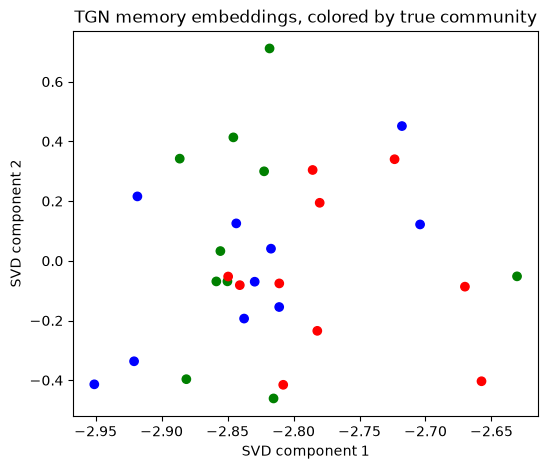

In [23]:
low_dim = TruncatedSVD(n_components=2, random_state=0).fit_transform(z_final)

colors = ['green'] * 10 + ['red'] * 10 + ['blue'] * 10
plt.figure(figsize=(6, 5))
plt.scatter(low_dim[:, 0], low_dim[:, 1], c=colors)
plt.xlabel('SVD component 1')
plt.ylabel('SVD component 2')
plt.title('TGN memory embeddings, colored by true community')
plt.show()

## Conclusion

Both checks tell the same story: the mean within-community and cross-community distances are essentially identical, the Adjusted Rand Index is close to zero (no better than a random clustering), and the visualization shows the three communities scattered on top of each other rather than forming separated clusters. Unlike the causality-aware DBGNN model from the previous notebook, TGN **fails to recover the planted temporal communities** in this data set, despite being trained on the exact same interactions.

The reason is architectural: TGN's memory update and its graph attention embedding only ever look at a node's own history and its most recent, *direct* neighbors. It has no mechanism to explicitly aggregate information along longer chains of time-respecting interactions that connect nodes several hops apart in time. Since the community signal in this data set is encoded purely in such longer time-respecting paths (recall that the static, time-aggregated topology is statistically indistinguishable from a random graph), a model that only reasons locally and pairwise, however well it models the timing of interactions, simply has no access to the relevant signal. This supports the conclusion that DBGNN's success in the previous notebook is not just a matter of being *temporally aware* in some general sense, but specifically relies on its explicit, higher-order modelling of time-respecting paths via De Bruijn graphs.